In [43]:
import pandas as pd

In [44]:
# seed3つの平均スコアを計算する関数
def get_avg_score(df):
    df["model"] = df["name"].str.replace(r"_seed\d+", "", regex=True)
    df_avg=df.groupby("model").mean(numeric_only=True).reset_index()
    return df_avg

In [45]:
# mlpのparamsを計算する関数
def mlp_params(input_dim,output_dim):
    # hidden size 1024, layers 2
    hidden_size = 1024
    layer1 = (input_dim * hidden_size) + hidden_size
    layer2 = (hidden_size * hidden_size) + hidden_size
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

# rnnのparamsを計算する関数
def rnn_params(input_dim,output_dim):
    # hidden size 400, layers 2, LSTM Cell
    hidden_size = 400
    layer1 = 4 * ((input_dim + hidden_size) * hidden_size + hidden_size)
    layer2 = 4 * ((hidden_size + hidden_size) * hidden_size + hidden_size)
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

# ncpのparamsを計算する関数
def ncp_params(input_dim, output_dim, units):
    layer1 = (input_dim * units) + units
    params_1 = units * 3 #gleak,vleak,cm
    params_2 = units * units * 5 # sigma, mu, w, erev, sparsity_mask
    params_3 = input_dim * units * 5 # sensory_sigma, sensory_mu, sensory_w, sensory_erev, sensory_sparsity_mask
    layer2 = (units * output_dim) + output_dim
    params = layer1 + params_1 + params_2 + params_3 + layer2
    return params

In [46]:
# MACsを計算する関数
# MLPの場合
def mlp_macs(input_dim, hidden_dim, output_dim):
    macs=(input_dim * hidden_dim + hidden_dim) + (hidden_dim * hidden_dim + hidden_dim) + (hidden_dim * output_dim + output_dim)
    nlops = hidden_dim * 2 + output_dim
    return macs

# RNNの場合
def rnn_macs(input_dim: int, hidden_dim: int, num_layers: int, output_dim: int = 0):
    # 1層目の入力は input_dim、以降の層の入力は hidden_dim
    macs_input_layer = 4 * (input_dim * hidden_dim + hidden_dim * hidden_dim + hidden_dim)  # +bias
    macs_deeper_layer = 4 * (hidden_dim * hidden_dim + hidden_dim * hidden_dim + hidden_dim)
    macs_lstm_all_layers = macs_input_layer + (num_layers - 1) * macs_deeper_layer

    macs_output = 0
    if output_dim and output_dim > 0:
        macs_output = hidden_dim * output_dim + output_dim  # +bias

    macs_per_step = macs_lstm_all_layers + macs_output

    return macs_per_step

# NCPの場合
def ncp_macs(input_dim: int, units: int, output_dim: int, ode_unfolds: int, k_nl: int = 1):
    macs_core_per_unfold = (units * units) * 2 + 4
    nlops_core_per_unfold = units * units

    macs_per_step = ode_unfolds * macs_core_per_unfold * units
    nlops_per_step = ode_unfolds * (nlops_core_per_unfold + units) + input_dim

    return macs_per_step

In [ ]:
import re
def calculate_model_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "params"] = mlp_params(input_dim, output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "params"] = rnn_params(input_dim, output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "params"] = ncp_params(input_dim, output_dim, u)
        else:
            raise ValueError("Unknown model")
    return df

def calculate_macs_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "macs"] = mlp_macs(input_dim, 1024, output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "macs"] = rnn_macs(input_dim, 400, 2, output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "macs"] = ncp_macs(input_dim, u, output_dim, 3)
        else:
            raise ValueError("Unknown model")
    return df

In [48]:
df_lift=pd.read_csv('/work/robomimic/csv/lift/lift-best.csv')
df_can=pd.read_csv('/work/robomimic/csv/can/can-best.csv')
df_square=pd.read_csv('/work/robomimic/csv/square/square-best.csv')
df_can_avg=get_avg_score(df_can)
df_can_avg=calculate_model_size(df_can_avg, "can")
df_can_avg=calculate_macs_size(df_can_avg, "can")
df_lift_avg=get_avg_score(df_lift)
df_lift_avg=calculate_model_size(df_lift_avg, "lift")
df_lift_avg=calculate_macs_size(df_lift_avg, "lift")
df_square_avg=get_avg_score(df_square)
df_square_avg=calculate_model_size(df_square_avg, "square")
df_square_avg=calculate_macs_size(df_square_avg, "square")

In [52]:
print(df_square_avg[["model","macs", "params","return","avg_policy_latency_ms", "avg_gpu_memory_increase_mb"]])

           model         macs     params    return  avg_policy_latency_ms  \
0        bc-pure    1081351.0  1081351.0  0.390000               0.875822   
1    bc-rnn-pure    1962807.0  1962807.0  0.670000               1.152379   
2  ncp_u128_best   12584448.0   100999.0  0.453333               1.355979   
3  ncp_u256_best  100666368.0   365831.0  0.600000               1.042837   
5   ncp_u64_best    1573632.0    30023.0  0.136667               4.558799   

   avg_gpu_memory_increase_mb  
0                   25.626953  
1                   39.490214  
2                    1.341309  
3                    4.924805  
5                    0.400879  


In [50]:
# u512を除外する
df_square_avg=df_square_avg[~df_square_avg["model"].str.contains("u512")]
df_can_avg=df_can_avg[~df_can_avg["model"].str.contains("u512")]
df_lift_avg=df_lift_avg[~df_lift_avg["model"].str.contains("u512")]

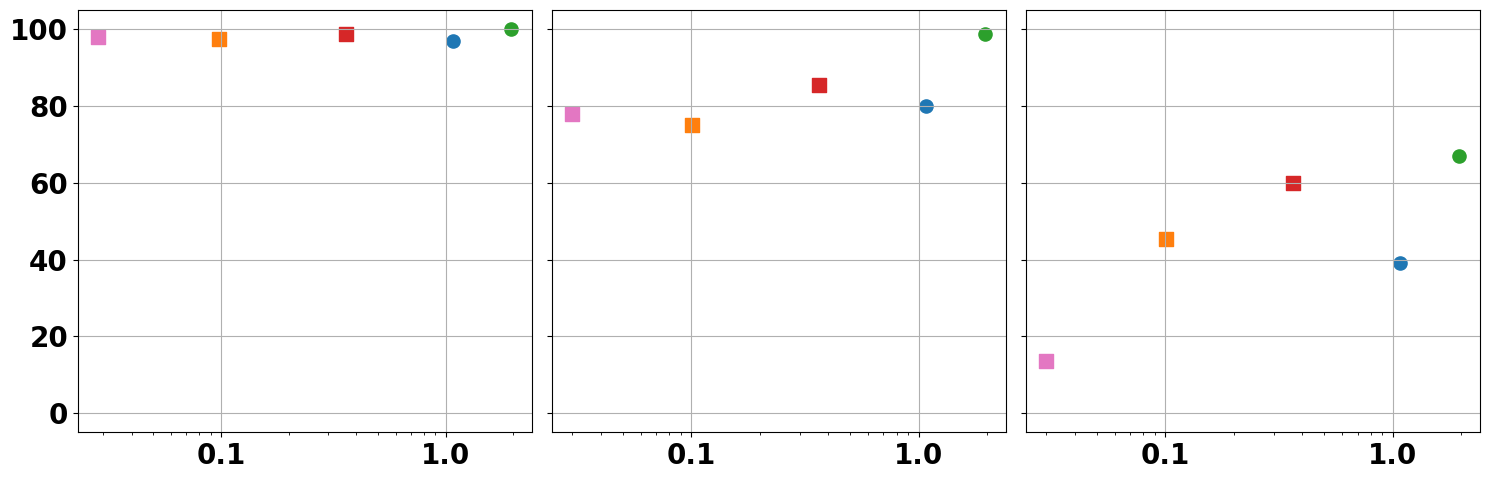

In [51]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({   
    "xtick.labelsize": 20,   # x軸目盛
    "ytick.labelsize": 20,   # y軸目盛
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = {
    "Lift": df_lift_avg,
    "Can": df_can_avg,
    "Square": df_square_avg
}

custom_colors = [
    "#1f77b4",  # 青
    "#2ca02c",  # 緑
    "#e377c2",  # ピンク
    "#ff7f0e",  # オレンジ
    "#d62728",  # 赤
    "#bcbd22",
    "#9467bd",
    "#8c564b",
    "#7f7f7f",
    "#17becf"
]

# 明示マップ（モデル名に応じた色）
explicit_color = {
    "bc-pure": "#1f77b4",       # mlp -> 青
    "bc-rnn-pure": "#2ca02c",   # rnn -> 緑
    "ncp_u64_best": "#e377c2",       # u64 -> ピンク
    "ncp_u128_best": "#ff7f0e",      # u128 -> オレンジ
    "ncp_u256_best": "#d62728",      # u256 -> 赤
}

model_styles = {}

def get_style(model):
    # 既定の色を優先
    if model in explicit_color:
        color = explicit_color[model]
    else:
        # フォールバックはこれまで通りのローテーション
        color = custom_colors[len(model_styles) % len(custom_colors)]
    marker = "s" if "ncp" in model.lower() else "o"
    model_styles[model] = {"color": color, "marker": marker}
    return model_styles[model]

for ax, (title, df) in zip(axes, datasets.items()):
    for model in df["model"].unique():
        sub = df[df["model"] == model]
        style = get_style(model)
        size = 90 if "ncp" in model.lower() else 90

        ax.scatter(
            sub["params"],
            sub["success_rate"]*100,
            s=size,
            color=style["color"],
            marker=style["marker"]
        )

    ax.set_xscale("log")
    ax.grid(True)

for ax in axes:
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}")
    )

for ax in axes:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    ax.set_ylim([-5, 105])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()